In [74]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LinearRegression, Ridge, Lasso, ElasticNet
from sklearn.metrics import r2_score, mean_absolute_error, mean_squared_error

import joblib

In [75]:
df = pd.read_csv("Cellphone.csv")

df.head()

,Product_id,Price,Sale,weight,resoloution,ppi,cpu core,cpu freq,internal mem,ram,RearCam,Front_Cam,battery,thickness
0,203,2357,10,135.0,5.2,424,8,1.35,16.0,3.000,13.00,8.0,2610,7.4
1,880,1749,10,125.0,4.0,233,2,1.30,4.0,1.000,3.15,0.0,1700,9.9
2,40,1916,10,110.0,4.7,312,4,1.20,8.0,1.500,13.00,5.0,2000,7.6
3,99,1315,11,118.5,4.0,233,2,1.30,4.0,0.512,3.15,0.0,1400,11.0
4,880,1749,11,125.0,4.0,233,2,1.30,4.0,1.000,3.15,0.0,1700,9.9


In [76]:
df.shape    
df.info()
df.describe()   
df.isnull().sum()



<class 'pandas.core.frame.DataFrame'>
RangeIndex: 161 entries, 0 to 160
Data columns (total 14 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   Product_id    161 non-null    int64  
 1   Price         161 non-null    int64  
 2   Sale          161 non-null    int64  
 3   weight        161 non-null    float64
 4   resoloution   161 non-null    float64
 5   ppi           161 non-null    int64  
 6   cpu core      161 non-null    int64  
 7   cpu freq      161 non-null    float64
 8   internal mem  161 non-null    float64
 9   ram           161 non-null    float64
 10  RearCam       161 non-null    float64
 11  Front_Cam     161 non-null    float64
 12  battery       161 non-null    int64  
 13  thickness     161 non-null    float64
dtypes: float64(8), int64(6)
memory usage: 17.7 KB


Product_id      0
Price           0
Sale            0
weight          0
resoloution     0
ppi             0
cpu core        0
cpu freq        0
internal mem    0
ram             0
RearCam         0
Front_Cam       0
battery         0
thickness       0
dtype: int64

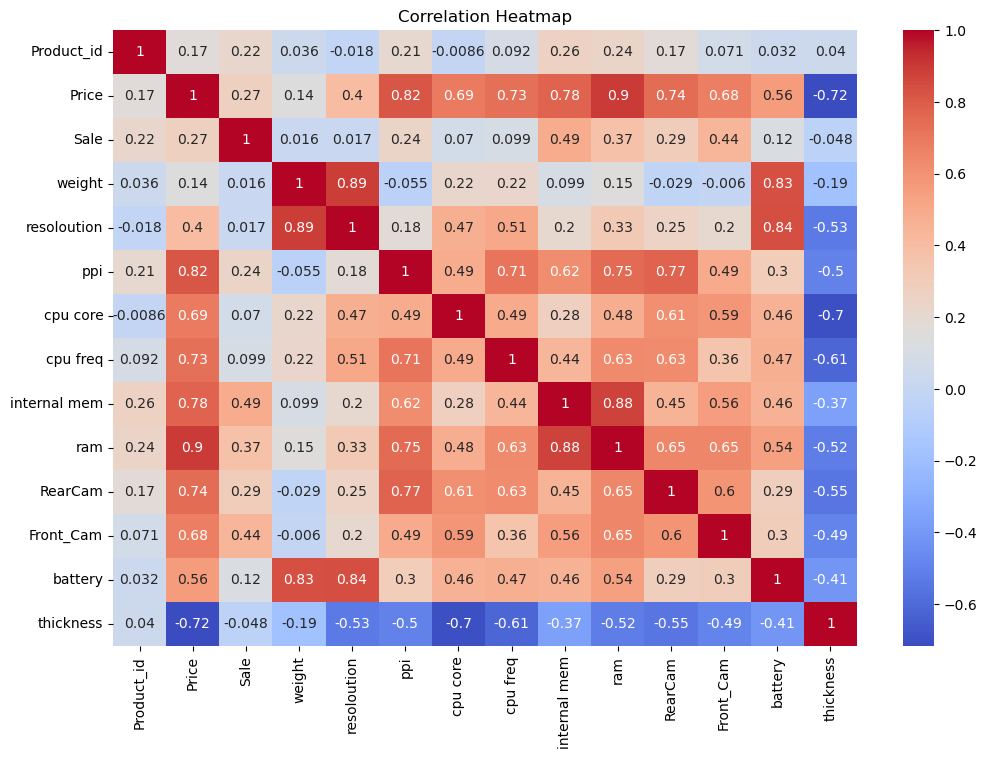

In [77]:
plt.figure(figsize=(12,8))
sns.heatmap(df.corr(), annot=True, cmap='coolwarm')
plt.title("Correlation Heatmap")
plt.show()

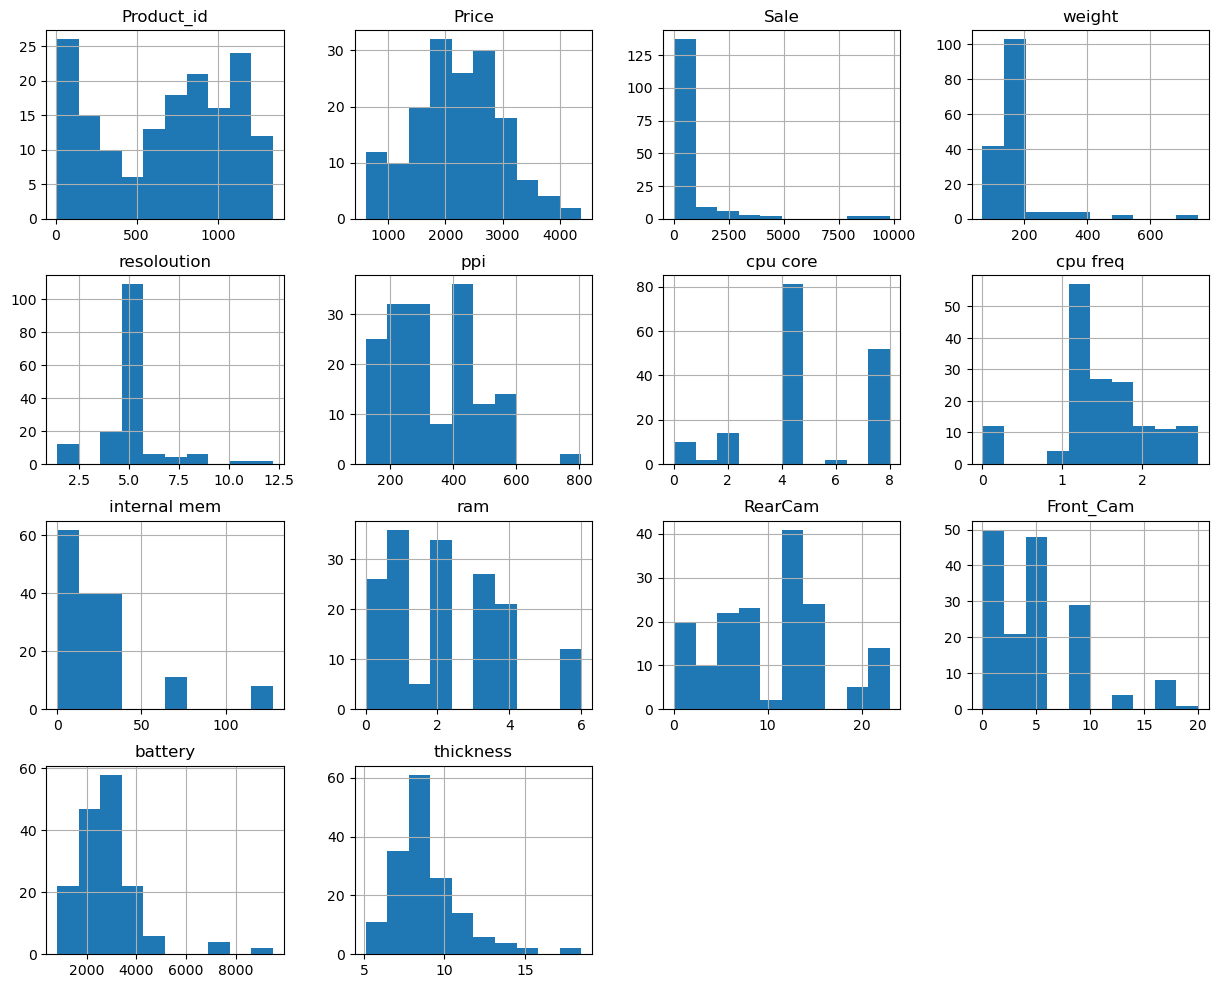

In [78]:
df.hist(figsize=(15,12))
plt.show()

In [79]:
df.skew()

Product_id     -0.216869
Price           0.052347
Sale            4.269384
weight          3.981756
resoloution     1.176110
ppi             0.602503
cpu core       -0.009077
cpu freq       -0.512663
internal mem    2.389683
ram             0.792698
RearCam         0.106929
Front_Cam       1.169750
battery         2.092660
thickness       1.587680
dtype: float64

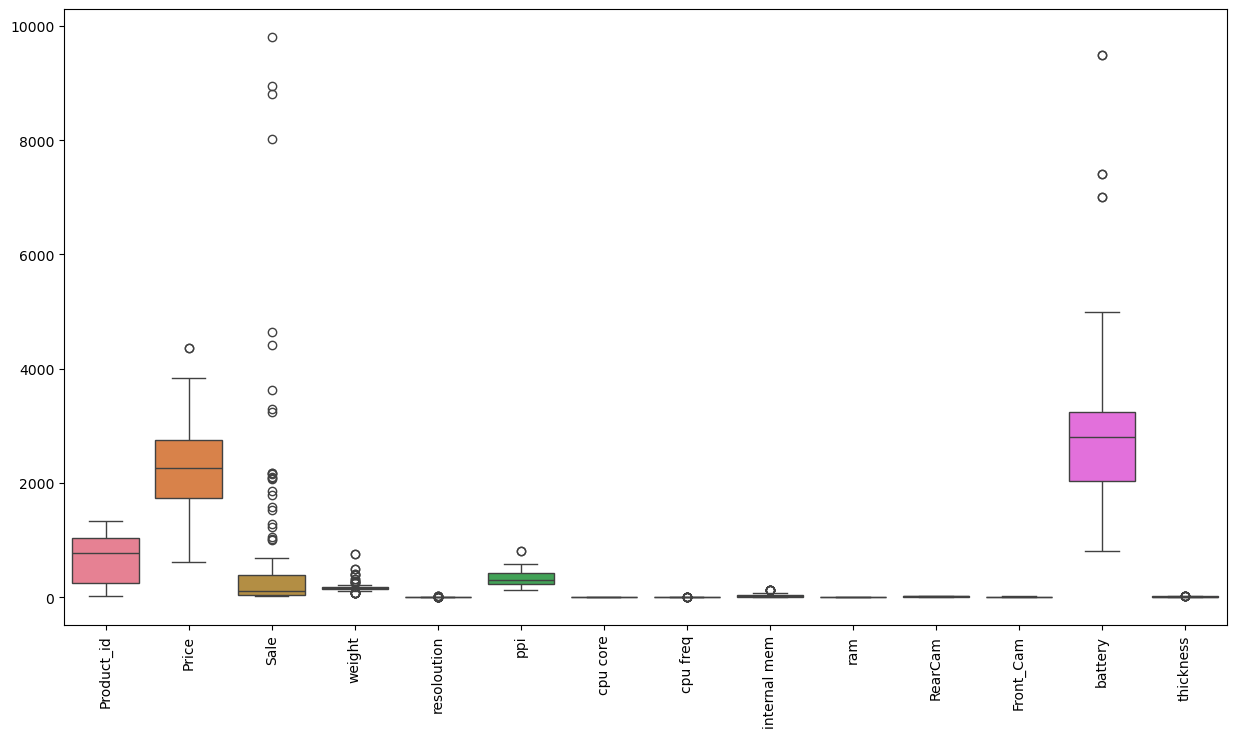

In [80]:
plt.figure(figsize=(15,8))
sns.boxplot(data=df)
plt.xticks(rotation=90)
plt.show()

In [81]:
X = df.drop("price", axis=1)
y = df["price"]

KeyError: "['price'] not found in axis"

In [ ]:
price_range
X = df.drop("price_range", axis=1)
y = df["price_range"]

In [ ]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

In [ ]:
scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

In [ ]:
lr = LinearRegression()

lr.fit(X_train_scaled, y_train)

y_pred = lr.predict(X_test_scaled)

print("R2 Score:", r2_score(y_test, y_pred))
print("MAE:", mean_absolute_error(y_test, y_pred))
print("RMSE:", np.sqrt(mean_squared_error(y_test, y_pred)))

In [ ]:
ridge = Ridge(alpha=1.0)

ridge.fit(X_train_scaled, y_train)

ridge_pred = ridge.predict(X_test_scaled)

print("Ridge R2:", r2_score(y_test, ridge_pred))    

In [ ]:
lasso = Lasso(alpha=0.1)

lasso.fit(X_train_scaled, y_train)

lasso_pred = lasso.predict(X_test_scaled)

print("Lasso R2:", r2_score(y_test, lasso_pred))

In [ ]:
elastic = ElasticNet(alpha=0.1, l1_ratio=0.5)

elastic.fit(X_train_scaled, y_train)

elastic_pred = elastic.predict(X_test_scaled)

print("ElasticNet R2:", r2_score(y_test, elastic_pred))

In [ ]:
results = pd.DataFrame({
    "Model": ["Linear", "Ridge", "Lasso", "ElasticNet"],
    "R2 Score": [
        r2_score(y_test, y_pred),
        r2_score(y_test, ridge_pred),
        r2_score(y_test, lasso_pred),
        r2_score(y_test, elastic_pred)
    ]
})

results

In [ ]:
import joblib

joblib.dump(ridge, "model.pkl")
joblib.dump(scaler, "scaler.pkl")

print("Model Saved Successfully")

In [ ]:
import joblib

# Save model
joblib.dump(ridge, "model.pkl")

# Save scaler
joblib.dump(scaler, "scaler.pkl")

print("Model and Scaler Saved Successfully")

In [ ]:
ridge.fit(X_train_scaled, y_train)  


In [ ]:
scaler.fit_transform()


In [ ]:
scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

In [ ]:
ridge = Ridge()

ridge.fit(X_train_scaled, y_train)

In [ ]:
import joblib

joblib.dump(ridge, "model.pkl")
joblib.dump(scaler, "scaler.pkl")

print("Model and Scaler Saved Successfully")